<a href="https://colab.research.google.com/github/vcellmike/PatternsFormation/blob/main/Working/2025_06_17_NN_classifier_based_on_manual_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import json
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, classification_report
from transformers import AutoModel, AutoTokenizer, get_scheduler
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
from tqdm.notebook import tqdm, trange
from time import perf_counter
from PIL import Image
import pandas as pd
#from google.colab import drive
from PIL import Image
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

print("all dependencies present")

all dependencies present


In [5]:
# set random seeds for repeatability
import numpy as np
import random

# Sets a random seed of 42 for all modules
def set_seed(seed_val):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)

seed_val = 42
set_seed(seed_val)

In [8]:
# unzip the VCell simulation images
!tar -xf "./content/05-09-2024_all_images.zip" -C "./content"
!tar -xf "./content/Generated Images.zip" -C "./content"
!tar -xf "./content/Generated_Images_7-2-24.zip" -C "./content"
!echo Unzip Complete

Unzip Complete


In [10]:
## Returns a list of all files and folders in the folder
dir_1 = os.listdir("./content/05-09-2024_all_images/")
dir_2 = os.listdir("./content/Generated Images/")
dir_3 = os.listdir("./content/Generated_Images_7-2-24/")

In [12]:
# Opens the pickle file
with open("./content/2024-08-15_manual_classification.pkl", 'rb') as f:
  feats_df = pickle.load(f) # deserialize using load()

In [13]:
# Loads in feats_df
feats_df.head()
feats_df.shape

(7307, 5)

In [14]:
feats_df

,class,noise,path,seed,dir
0,3,4,noise 4 20604.0.png,20604.0,/content/Generated_Images_7-2-24/
1,3,6,noise 6 20289.0.png,20289.0,/content/Generated_Images_7-2-24/
2,4,23782.0,noise 6 23782.0.png,23782.0,/content/Generated Images/
3,2,2,7761.png,7761,/content/05-09-2024_all_images/
4,1,2,8366.png,8366,/content/05-09-2024_all_images/
...,...,...,...,...,...
7302,1,5,noise 5 21947.0.png,21947.0,/content/Generated_Images_7-2-24/
7303,2,4,noise 4 23369.0.png,23369.0,/content/Generated_Images_7-2-24/
7304,2,2,1663.png,1663,/content/05-09-2024_all_images/
7305,2,7,noise 7 22084.0.png,22084.0,/content/Generated_Images_7-2-24/


In [15]:
# finds instances where the classes are not defined in the dataframe and removes them
# Creates a counter at 0
counter = 0

# Creates a list of non-integer values
non_ints = []

# Cuts down the dataframe and isolates "class", and loops through each value.
for i in feats_df["class"]:
  # Try-Except statement to ensure all numbers are integer values
  try:
    a = int(i)

  except:
    non_ints.append(counter)

  counter += 1

# Drops all the values with non_int values
feats_df = feats_df.drop(non_ints, axis = "rows")
# Resets the index of all the rows so you don't get 1, 2, 3, 5, 7, 8, 12...
feats_df.reset_index(inplace = True, drop = True)

# changes classes to integers and subtracts 1 so it starts at 0
feats_df["class"] = np.array(feats_df["class"].astype(int) - 1).astype(int)

# show how many images there are in each class
print(np.unique(np.array(feats_df["class"]), return_counts = True))

(array([0, 1, 2, 3, 4, 5, 6]), array([1993, 2329, 2330,  122,  330,  165,   35]))


In [16]:
# change the paths to be consistent with the current locations
new_dirs = []
dirs = list(feats_df["dir"])
for dir in dirs:
  new_dir = f"/content/{dir[9:-1]}/"
  new_dirs.append(new_dir)

feats_df["dir"] = new_dirs
feats_df.head()


,class,noise,path,seed,dir
0,2,4,noise 4 20604.0.png,20604.0,/content/Generated_Images_7-2-24/
1,2,6,noise 6 20289.0.png,20289.0,/content/Generated_Images_7-2-24/
2,3,23782.0,noise 6 23782.0.png,23782.0,/content/Generated Images/
3,1,2,7761.png,7761,/content/05-09-2024_all_images/
4,0,2,8366.png,8366,/content/05-09-2024_all_images/


In [20]:
# check if the paths in the dataframe are real
doom_list = []
for i in range(feats_df.shape[0]):
  path = feats_df["dir"][i] + feats_df["path"][i]
  if os.path.exists("./" + path) is False:
    doom_list.append(i)

print(len(doom_list))

0


In [24]:
df_train = feats_df.sample(frac = 0.068, random_state=42)
df_train

,class,noise,path,seed,dir
5152,1,3,noise 3 21029.0.png,21029.0,/content/Generated_Images_7-2-24/
5456,0,5,noise 5 20521.0.png,20521.0,/content/Generated_Images_7-2-24/
3859,1,2,4704.png,4704,/content/05-09-2024_all_images/
1918,0,2,8055.png,8055,/content/05-09-2024_all_images/
7300,1,4,noise 4 23369.0.png,23369.0,/content/Generated_Images_7-2-24/
...,...,...,...,...,...
2509,3,2,2521.png,2521,/content/05-09-2024_all_images/
6119,0,2,4326.png,4326,/content/05-09-2024_all_images/
2650,1,7,noise 7 23812.0.png,23812.0,/content/Generated_Images_7-2-24/
5072,1,7,noise 7 21272.0.png,21272.0,/content/Generated_Images_7-2-24/


In [26]:
# Make train,test,val datasets

# Creates a training, validation, and test data set with 80 percent
df_train = feats_df.sample(frac = 0.068, random_state = 42)
df_train.reset_index(inplace = True, drop = True)
df_val_test = feats_df.drop(df_train.index)

p_out = 1

# Validation and test data set
df_val_test = df_val_test.sample(frac = p_out, random_state = 42)

# Takes a random 50 percent of the sample and assigns it to validation
df_val = df_val_test.sample(frac = 0.068, random_state = 42)

# Drop the validation values and creates the test data set.
df_test = df_val_test.drop(df_val.index)

# Resets indexes on both validation and test data sets
# Breakdown of data usage: 80% - Train; 10% - Test; 10% - Validation
df_val.reset_index(inplace = True, drop = True)
df_test.reset_index(inplace = True, drop = True)

# show the size of each dataset
print("Training dataset size: ", df_train.shape)
print("Validation dataset size: ", df_val.shape)
print("Testing datset size: ", df_test.shape)

Training dataset size:  (497, 5)
Validation dataset size:  (463, 5)
Testing datset size:  (6344, 5)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
# TRAINING SETTINGS

# Number of times the NN goes through the entire data set
NUM_EPOCHS = 5

# LEARNING RATE SETTINGS

# Adjusts how much the model adjusts in relation to the loss model
# Typically between 0 and 1
BASE_LR = 1e-5 # this should be small(er)

DECAY_WEIGHT = 0.1 # factor by which the learning rate is reduced.

# LR = BASE_LR * (DECAY_WEIGHT)^(current_epoch - EPOCH_DECAY)
EPOCH_DECAY = 15 # number of epochs after which the learning rate is decayed exponentially by DECAY_WEIGHT.


# # DATASET INFO
# NUM_CLASSES = 2 # set the number of classes in your dataset
# # DATA_DIR = 'hymenoptera_data/' # to run with the sample dataset, just set to 'hymenoptera_data'


# DATALOADER PROPERTIES

# Batch Size dictates # of data points used in one batch

# Original B_S was 64
BATCH_SIZE = 64

# GPU SETTINGS
CUDA_DEVICE = 0 # Enter device ID of your gpu if you want to run on gpu. Otherwise neglect.
GPU_MODE = 1 # set to 1 if want to run on gpu.


# # SETTINGS FOR DISPLAYING ON TENSORBOARD
# USE_TENSORBOARD = 0 #if you want to use tensorboard set this to 1.
# TENSORBOARD_SERVER = "YOUR TENSORBOARD SERVER ADDRESS HERE" # If you set.
# EXP_NAME = "Nathan_Car" # if using tensorboard, enter name of experiment you want it to be displayed as.


use_gpu = GPU_MODE
if use_gpu:
    torch.cuda.set_device(CUDA_DEVICE)
# show transforms and dataset loader, from https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

In [ ]:
# Transform the data
# Takes an image and a node
def data_transforms(image, mode):
  # Conditioned on mode
  # If training mode
  if mode == "train":
    # Train the neural network model
    # PyTorch function
    # Creates a composition of multiple transformations
    # Flips the image horizontally
    # Flips the image vertically
    # Saves it to a Tensor object
    # Question: what is the purpose of data augmentation if we don't have the true class values of the augmented shapes.
    # ie. are the patterns' classes equivalent regardless of flips or rotations?
    tnsfrm = transforms.Compose([
            # transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(), #.5
            transforms.RandomVerticalFlip(), #.5
            transforms.ToTensor()
        ])

# Probabilites:
    # Of both occuring: .25
    # Of either occuring: .5
    # Of neither occuring .25

  elif mode == "val":
    # Creates a composition of transformations: Converts to Tensor and resizes it
    tnsfrm = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((224,224))
    ])

  # Transforms the iamge
  img = tnsfrm(image)

  # Concatonate the three image tensors together at columns
  # Question - Purpose of concatanation?
  img = torch.cat((img,img,img),0)

  return img

# Create a class
# Common de facto way of implementing custom data set
# Inherits the PyTorch Dataset class
class CustomImageDataset(Dataset):
    # Initialize
    # Takes an annotations_file
    def __init__(self, annotations_file, transform, mode, target_transform):
      # image dir and file_name
        self.img_dir = annotations_file["dir"]
        self.path = annotations_file["path"]
      # gets the labels from the dataframe provided in the dataloader
        self.img_labels = annotations_file["class"]
      #transform is defined previously
        self.transform = transform
      #no target transforms for this task
        self.target_transform = target_transform
      # training mode
        self.mode = mode

    def __len__(self):
      #gives the size of whatever dataset is being loaded
        return len(self.img_labels)

    # Get image located at idx
    def __getitem__(self, idx):
        #get the path to the image
        img_path = self.img_dir[idx] + self.path[idx]
        #loads in the image
        image = Image.open(img_path)
        #gets the corresponding label
        label = self.img_labels.iloc[idx]
        label_list = np.zeros(7)
        label_list[label] = 1
        # does the transforms
        if self.transform:
            image = self.transform(image,self.mode)
        if self.target_transform:
            label = self.target_transform(label)
        return image.to(torch.float32), torch.tensor(label)

# Creates a data set dictionary
dsets = {}

# Appends train and validation data sets to the dictionary
dsets["train"] = CustomImageDataset(df_train, data_transforms, "train", None)
dsets["val"] = CustomImageDataset(df_val, data_transforms, "val", None)

# Creates a data loader object for training and value data sets
train_dataloader = DataLoader(dsets["train"], batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dsets["val"], batch_size=BATCH_SIZE, shuffle=True)

# Dictionary for data loaders
dset_loaders = {"train":train_dataloader, "val":val_dataloader}

# Size of each data sets
dset_sizes = {}
dset_sizes['train'] = df_train.shape[0]
dset_sizes['val'] = df_val.shape[0]

print(dset_sizes)

{'train': 5843, 'val': 730}


In [ ]:
import time
from torch.autograd import Variable
import copy

# Function for training a model
def train_model(model, criterion, optimizer, lr_scheduler, num_epochs):
    since = time.time()

    best_model = model
    best_loss = float('inf')

    # accuracies = {'train': [], 'val': []}
    losses = {'train': [], 'val': []}
    for epoch in range(num_epochs):
        print('-' * 10)
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                optimizer = lr_scheduler(optimizer, epoch)
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to eval mode for validation (no need to track gradients)

            running_loss = 0.0
            # running_corrects = 0

            counter=0
            # Iterate over data, getting one batch of inputs (images) and labels each time.
            for data in dset_loaders[phase]:
                inputs, labels = data

                if use_gpu:
                    try:
                        inputs, labels = Variable(inputs.float().cuda()), Variable(labels.long().cuda())
                    except Exception as e:
                        print("ERROR! here are the inputs and labels before we print the full stack trace:")
                        print(inputs, labels)
                        raise e
                else:
                    inputs, labels = Variable(inputs), Variable(labels)

                # Set gradient to zero to delete history of computations in previous epoch. Track operations so that differentiation can be done automatically.
                optimizer.zero_grad()
                outputs = model(inputs)
                # _, preds = torch.max(outputs.data, 1)
                # preds = preds.to(torch.float32)
                # print(preds)
                loss = criterion(outputs, labels).to(torch.float32)

                # print(labels)
                # print(outputs)
                # print(loss)


                # Print a line every 10 batches so you have something to watch and don't feel like the program isn't running.
                if counter%10==0:
                    print("Reached batch iteration", counter)

                counter+=1

                # print(inputs.size())
                # print(outputs.size())
                # print(loss.size())

                # backward + optimize only if in training phase
                if phase == 'train':
                    loss.backward()
                    optimizer.step()
                try:
                    running_loss += loss.item()
                    # running_corrects += torch.sum(preds == labels.data)
                except:
                    print('unexpected error, could not calculate loss or do a sum.')

            epoch_loss = running_loss / dset_sizes[phase]
            # epoch_acc = running_corrects.item() / float(dset_sizes[phase])
            print('Epoch' + str(epoch) + "loss = " + str(epoch_loss))
            # accuracies[phase].append(epoch_acc)
            losses[phase].append(epoch_loss)

            # deep copy the model
            if phase == 'val':
                # if USE_TENSORBOARD:
                #     foo.add_scalar_value('epoch_loss', epoch_loss,step=epoch)
                #     foo.add_scalar_value('epoch_acc', epoch_acc,step=epoch)
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model = copy.deepcopy(model)
                    print('new best loss =', best_loss)
    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best loss: {:4f}'.format(best_loss))
    print('returning and looping back')

    return best_model, losses


# This function changes the learning rate as the model trains.
def exp_lr_scheduler(optimizer, epoch, init_lr=BASE_LR, lr_decay_epoch=EPOCH_DECAY):
    """Decay learning rate by a factor of DECAY_WEIGHT every lr_decay_epoch epochs."""
    lr = init_lr * (DECAY_WEIGHT**(epoch // lr_decay_epoch))

    if epoch % lr_decay_epoch == 0:
        print('LR is set to {}'.format(lr))

    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    return optimizer




#start with resnet50
model_ft = models.resnet50(pretrained=True)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 7)

#set loss function to binary crossentropy
criterion = nn.CrossEntropyLoss()

if use_gpu:
    criterion.cuda()
    model_ft.cuda()

optimizer_ft = optim.AdamW(model_ft.parameters(), lr=0.0001)


# Run the functions and save the best model in the function model_ft.
model_ft, losses = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=NUM_EPOCHS)

for split in ['train', 'val']:
    # print(split, "accuracies by epoch:", accuracies[split])
    print(split, "losses by epoch:", losses[split])

print("")

# Save model
# torch.save(model_ft.state_dict(), 'fine_tuned_best_model.pt')

import datetime

# Get the current datetime
now = datetime.datetime.now()

# Convert to timestamp
timestamp = now.timestamp()
print(f"Current timestamp: {timestamp}")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


----------
Epoch 0/4
----------
LR is set to 1e-05
Reached batch iteration 0
Reached batch iteration 10
Reached batch iteration 20
Reached batch iteration 30
Reached batch iteration 40
Epoch0loss = 0.005370486719588313
Reached batch iteration 0


OutOfMemoryError: CUDA out of memory. Tried to allocate 392.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 150.12 MiB is free. Process 305410 has 14.59 GiB memory in use. Of the allocated memory 13.57 GiB is allocated by PyTorch, and 907.30 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# torch.save(model_ft.state_dict(), "/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-15_best_classification_model.pth")
# change path

In [ ]:
# #initialize new model with same architecture as the one that was trained
# pred_model = models.resnet50(pretrained=False)
# num_ftrs = pred_model.fc.in_features
# pred_model.fc = nn.Linear(num_ftrs, 7)
# pred_model.cuda()

# !!!!!!! #apply saved weights to the model
# pred_model.load_state_dict(torch.load("/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-15_best_classification_model.pth"))

# #set model mode to eval
# pred_model.eval()

In [ ]:
# make a data_transforms function for running the NN on the rest of the images in the dataframe
def data_transforms(image, mode):
  if mode == "train":
    tnsfrm = transforms.Compose([
            # transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ToTensor()
        ])
  elif mode == "val":
    tnsfrm = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((224,224))
    ])

  img = tnsfrm(image)
  # Input of architecture is RGB, requires three channels
  img = torch.cat((img,img,img),0)
  return img

#choose image

#make predictions on the image
preds = []
counter = 0

with torch.no_grad():
  for i in range(df_val.shape[0]):
    pred_image = np.array(Image.open(df_val["dir"][i] + df_val["path"][i]))
    # print(np.array(pred_image).shape)
    pred_img_transformed = data_transforms(pred_image,"val")
    # print(pred_img_transformed.size())
    # print(pred_img_transformed.unsqueeze(0).size())
    preds.append((model_ft(pred_img_transformed.unsqueeze(0).cuda())))

    if counter % 250 == 0:
      print(counter)

    counter += 1


# fig,ax = plt.subplots(2)
# pred_img_transformed = np.array(pred_img_transformed).transpose(1,2,0)

# ax[0].imshow(pred_image)
# ax[1].imshow(pred_img_transformed)

# # im = im.transpose(2,0,1)

In [ ]:
# add predicted class to the test_df

pred_class = []

for pred in preds:
  p = pred.cpu().numpy()
  argmax = np.argmax(p)
  pred_class.append(argmax)

df_val["pred_class"] = pred_class

###### Control Image (all params as original):

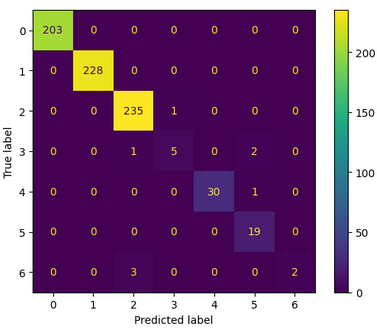

In [ ]:
# confusion matrix
from sklearn import metrics

actual = df_val["class"]
predicted = df_val["pred_class"]

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1 , 2, 3, 4, 5, 6])

cm_display.plot()
plt.show()